### Supp Figure 1. Time under immobility

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map, ChangeofMind
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.changeOfMind_figures.supp_behavior_speed import (
    plot_speed_over_time,
    return_time_under_threshold,
    return_average_head_angular,
    plot_duration_under_threshold, plot_average_angular_speed, plot_integrated_phi)


In [6]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}
peak_day_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20220420'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110','20240113']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20240110'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20221024'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20230811'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20231108'

In [7]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="speed_profile")

[19:49:30][INFO] Spyglass: Starting {'export_id': 108}
INFO:spyglass:Starting {'export_id': 108}


### 0. Zoom-in head speed profile

In [8]:
duration_animals = {}
speed_animals = {}
speed_threshold = 6
for animal in list_of_days_animals.keys():
    duration_animals[animal], speed_animals[animal] = return_time_under_threshold(
        animal, -2, 5, speed_threshold)

/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/speed_zoom_in_molly.pdf
/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/speed_zoom_in_klein.pdf
/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/speed_zoom_in_julio.pdf


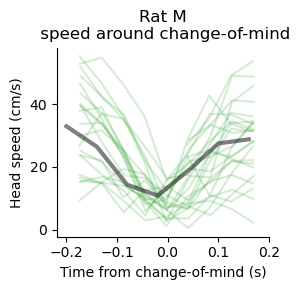

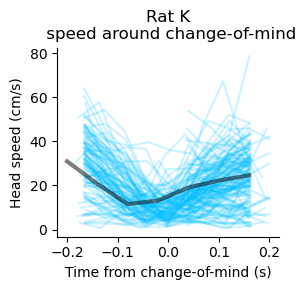

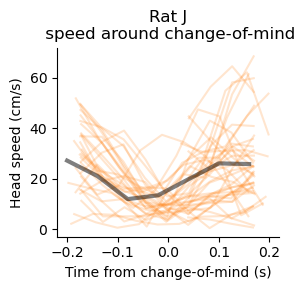

In [9]:
outputfolder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/"

for animal in ["molly","klein","julio"]:
    plot_speed_over_time(animal, speed_animals, -0.2, 0.2,
                         outputfolder)

### 1. Animal head speed

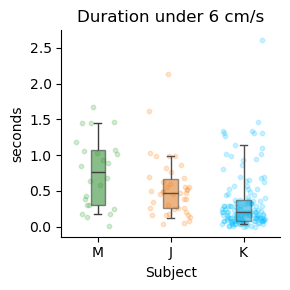

In [10]:
outputfolder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/"
plot_duration_under_threshold(duration_animals, speed_threshold, outputfolder)


### 2. Animal angular speed

In [11]:
average_animal = {}
angles_animal = {}
raw_angles_animal = {}
for animal in ["molly","julio","klein"]:
    average_animal[animal], angles_animal[animal], raw_angles_animal[animal] = return_average_head_angular(
        animal, -1, 2, imu_name = "big_acc_bias")

# For VTE detection in Johnson 2007: angular speed > 120 deg/s
# Johnson 2007 https://www.jneurosci.org/content/27/45/12176.long

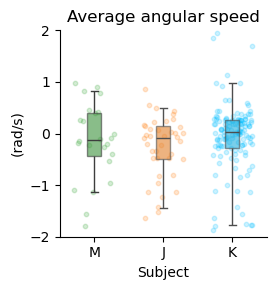

In [12]:
outputfolder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/"
plot_average_angular_speed(average_animal, outputfolder)

### 3. Integrated head angles

In [13]:
from position_tools import (
    get_angle,
    get_distance,
    get_speed,
    get_velocity,
    interpolate_nan,
)

In [14]:
trial_ind = 1
postion_info_gyro = raw_angles_animal[animal][trial_ind]

trial_speeds1 = get_velocity(
            np.array(postion_info_gyro.head_orientation),
            postion_info_gyro.index,
            sigma=0.001,
            sampling_frequency=np.median(np.diff(np.array(postion_info_gyro.index))))

trial_speeds2 = get_velocity(
            np.array(postion_info_gyro.head_orientation),
            postion_info_gyro.index,
            sigma=0.1,
            sampling_frequency=1/np.median(np.diff(np.array(postion_info_gyro.index))))

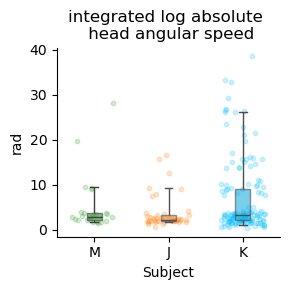

In [15]:
outputfolder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp1/"
plot_integrated_phi(angles_animal, outputfolder)

# Papale et al. 2012 and Schmidt et al., 2013

In [16]:
ExportSelection().stop_export(**paper_key, analysis_id="speed_profile")

### End here

In [142]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2/'

In [5]:
triggered_decode_parameter_name = "params_both_max_run_time_2_state"
for animal in ["molly"]:

    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)

    with open(output_path, 'rb') as file:
        # Deserialize the data and assign it to a variable
        data = pickle.load(file)

In [6]:
data.keys()

dict_keys(['all_theta_days', 't_axis', 'all_trial_info', 'all_speed_days', 'theta_mean', 'theta_sd', 'speed_mean', 'speed_sd'])

In [80]:
data['all_trial_info'][0]

[autoreload of spyglass.shijiegu.changeOfMind_figures.supp_behavior_speed failed: Traceback (most recent call last):
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/home/shijiegu/Documents/spyglass/

('molly20220416_.nwb', '08_Seq2Session4', 63)

In [20]:
data['all_theta_days'][0]

,0,amplitude,phase,time,zscored
time,,,,,
1.650151e+09,0.945821,114,0.330682,-5.000205,-0.259467
1.650151e+09,0.926495,112,0.385807,-4.999205,-0.287644
1.650151e+09,0.904360,110,0.440918,-4.998205,-0.315322
1.650151e+09,0.879473,108,0.496043,-4.997205,-0.342501
1.650151e+09,0.851920,106,0.551155,-4.996205,-0.369182
...,...,...,...,...,...
1.650151e+09,-0.985044,-80,2.968423,4.398821,-0.670649
1.650151e+09,-0.992360,-81,3.017905,4.399822,-0.660613
1.650151e+09,-0.997247,-82,3.067376,4.400821,-0.650451


In [18]:
len(data['all_theta_days'])

136

In [26]:
np.array(data['all_theta_days'][0].time)

array([-5.00020528, -4.99920511, -4.99820495, ...,  4.40082145,
        4.40182137,  4.40282154])

In [19]:
len(data['all_speed_days'])

136

In [17]:
np.diff(data['all_speed_days'][0].index)

array([0.00200009, 0.00200009, 0.00199986, ..., 0.00200009, 0.00199986,
       0.00200009])

In [82]:
data['all_speed_days'][0]

,head_position_x,head_position_y,head_orientation,head_velocity_x,head_velocity_y,head_speed
time,,,,,,
1.650151e+09,217.127717,223.923913,-0.726573,-4.651915,-18.831152,19.397231
1.650151e+09,217.130435,223.910326,-0.730848,-4.791600,-18.860851,19.459988
1.650151e+09,217.133152,223.896739,-0.735193,-4.932673,-18.893080,19.526386
1.650151e+09,217.135870,223.883152,-0.739550,-5.075093,-18.927920,19.596498
1.650151e+09,217.138587,223.869565,-0.743918,-5.218818,-18.965447,19.670390
...,...,...,...,...,...,...
1.650151e+09,124.171196,92.483696,-2.454376,-1.182697,0.507191,1.286862
1.650151e+09,124.198864,92.517045,-2.449756,-1.116024,0.575724,1.255774
1.650151e+09,124.210227,92.534091,-2.448373,-1.051182,0.642543,1.232009


In [30]:
test_pd.index[0]

1650150718.0446858

In [28]:
test_pd = data['all_speed_days'][0].head_speed

In [32]:
test_pd

time
1.650151e+09    19.397231
1.650151e+09    19.459988
1.650151e+09    19.526386
1.650151e+09    19.596498
1.650151e+09    19.670390
                  ...    
1.650151e+09     1.286862
1.650151e+09     1.255774
1.650151e+09     1.232009
1.650151e+09     1.215412
1.650151e+09     1.205702
Name: head_speed, Length: 4702, dtype: float64

In [35]:
test_pd[test_pd < 4]

time
1.650151e+09    3.809412
1.650151e+09    3.615206
1.650151e+09    3.420690
1.650151e+09    3.225874
1.650151e+09    3.030771
                  ...   
1.650151e+09    1.286862
1.650151e+09    1.255774
1.650151e+09    1.232009
1.650151e+09    1.215412
1.650151e+09    1.205702
Name: head_speed, Length: 513, dtype: float64